# EEL891 - 2026.01 -  Trabalho 2 - Aprendizado de máquina - Thiago Moutinho de Carvalho Maksoud - DRE 119048139

In [35]:
# imports necessarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [36]:
# carregando os dados
train_df = pd.read_csv('./data/trabalho2/conjunto_de_treinamento.csv')
test_df = pd.read_csv('./data/trabalho2/conjunto_de_teste.csv')

# guardando os ids do teste para a submissao final
test_ids = test_df['Id'].copy()

print(f"Treino original: {train_df.shape[0]} linhas")
print(f"Teste original: {test_df.shape[0]} linhas")

Treino original: 4683 linhas
Teste original: 2000 linhas


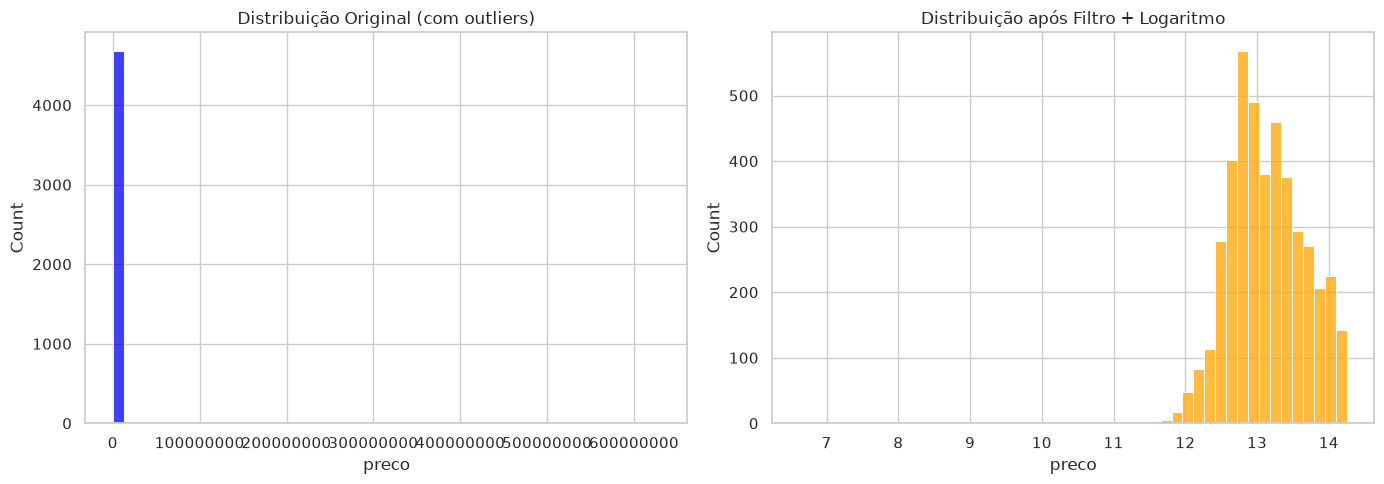

Treino após limpeza: 4361 linhas


In [37]:
# calculando os limites para remover outliers extremos do preco
Q1 = train_df['preco'].quantile(0.25)
Q3 = train_df['preco'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

# visualizando o impacto do logaritmo na variavel alvo (cauda longa)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_df['preco'], bins=50, ax=ax[0], color='blue')
ax[0].set_title('Distribuição Original (com outliers)')
ax[0].ticklabel_format(style='plain', axis='x')

# removendo os outliers do dataframe de treino
train_df = train_df[train_df['preco'] <= limite_superior].copy()

# aplicando log1p (log(1+x)) para normalizar a curva do preco
y_train = np.log1p(train_df['preco'])

sns.histplot(y_train, bins=50, ax=ax[1], color='orange')
ax[1].set_title('Distribuição após Filtro + Logaritmo')

plt.tight_layout()
plt.show()

print(f"Treino após limpeza: {train_df.shape[0]} linhas")

In [38]:
# preparando para feature engineering (juntando os datasets)
train_df['is_train'] = 1
test_df['is_train'] = 0

train_drop = train_df.drop(['Id', 'preco'], axis=1)
test_drop = test_df.drop(['Id'], axis=1)

df_full = pd.concat([train_drop, test_drop], ignore_index=True)

# criando novas features
df_full['area_total'] = df_full['area_util'] + df_full['area_extra']
df_full['area_por_quarto'] = df_full['area_util'] / (df_full['quartos'] + 1)

amenidades = ['churrasqueira', 'estacionamento', 'piscina', 'playground', 
              'quadra', 's_festas', 's_jogos', 's_ginastica', 'sauna', 'vista_mar']
df_full['total_amenidades'] = df_full[amenidades].sum(axis=1)

# transformando variaveis categoricas (one-hot encoding)
cat_cols = ['tipo', 'bairro', 'tipo_vendedor', 'diferenciais']
df_full = pd.get_dummies(df_full, columns=cat_cols, drop_first=True, dtype=int)

# separando treino e teste novamente
X_train = df_full[df_full['is_train'] == 1].drop(['is_train'], axis=1)
X_test = df_full[df_full['is_train'] == 0].drop(['is_train'], axis=1)

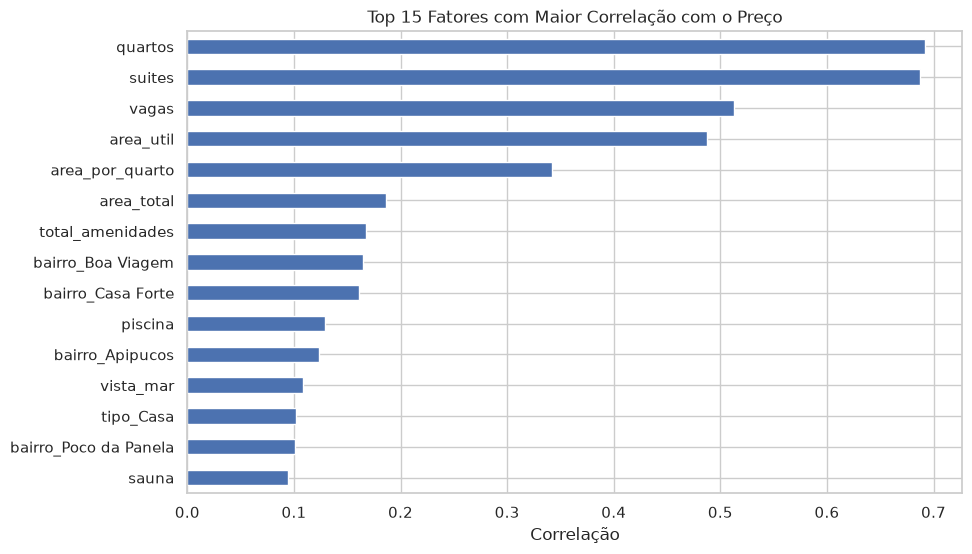

In [39]:
# analisando quais variaveis tem maior correlacao com o preco (agora em log)
X_train_corr = X_train.copy()
X_train_corr['log_preco'] = y_train.values

correlacoes = X_train_corr.corr()
top_features = correlacoes['log_preco'].sort_values(ascending=False)[1:16] # top 15

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh').invert_yaxis()
plt.title('Top 15 Fatores com Maior Correlação com o Preço')
plt.xlabel('Correlação')
plt.show()

In [40]:
# padronizando os dados 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# convertendo de volta para dataframe
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# configurando a validacao cruzada
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# instanciando o modelo campeao para tabular (xgboost)
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# avaliando com cross-validation
scores = cross_val_score(xgb, X_train_scaled, y_train, cv=kf, scoring='neg_root_mean_squared_error')
rmse_cv = np.mean(np.abs(scores))

print(f"RMSE Médio (Validação Cruzada - escala Log): {rmse_cv:.4f}")

RMSE Médio (Validação Cruzada - escala Log): 0.2169


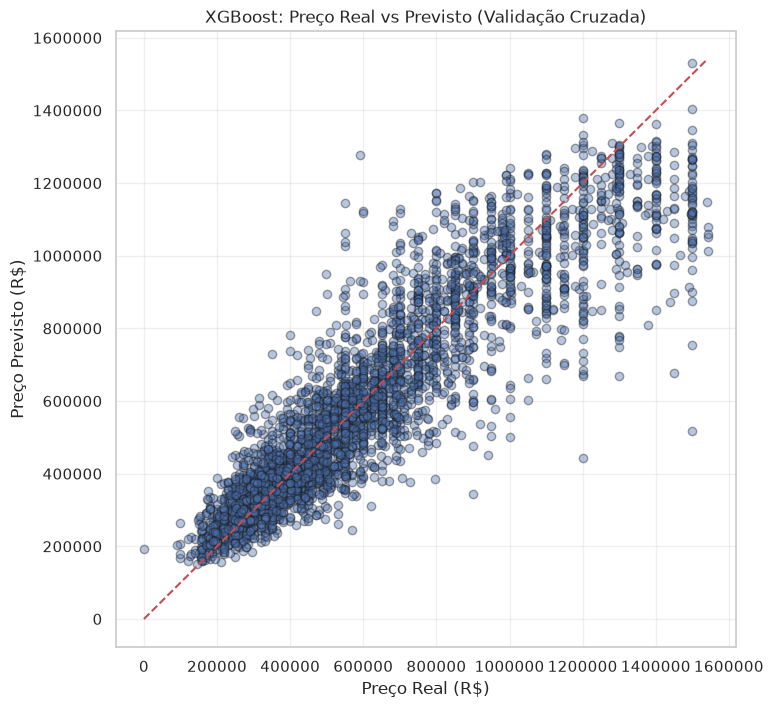

In [41]:
# pegando as previsoes da validacao cruzada pra checar o ajuste visualmente
log_cv_preds = cross_val_predict(xgb, X_train_scaled, y_train, cv=kf)

# revertendo o logaritmo para valores reais no grafico
y_train_real = np.expm1(y_train)
cv_preds_real = np.expm1(log_cv_preds)

plt.figure(figsize=(8, 8))
plt.scatter(y_train_real, cv_preds_real, alpha=0.4, edgecolors='k')
plt.plot([0, y_train_real.max()], [0, y_train_real.max()], 'r--') 

plt.xlabel('Preço Real (R$)')
plt.ylabel('Preço Previsto (R$)')
plt.title('XGBoost: Preço Real vs Previsto (Validação Cruzada)')
plt.ticklabel_format(style='plain', axis='both')
plt.grid(True, alpha=0.3)
plt.show()

In [42]:
# treinando o modelo final com 100% dos dados de treino disponiveis
xgb.fit(X_train_scaled, y_train)

# gerando as previsoes para o arquivo de teste
log_preds_test = xgb.predict(X_test_scaled)

# revertendo as previsoes do teste de log para reais
precos_reais_test = np.expm1(log_preds_test)

# criando e salvando o dataframe de submissao
submission = pd.DataFrame({
    'Id': test_ids,
    'preco': precos_reais_test
})

submission.to_csv('submission_trabalho2.csv', index=False)
print("Arquivo 'submission_trabalho2.csv' gerado com sucesso!")
submission.head()

Arquivo 'submission_trabalho2.csv' gerado com sucesso!


,Id,preco
0,0,1.265583e+06
1,1,2.691472e+05
2,2,6.355536e+05
3,3,2.354726e+05
4,4,2.883052e+05
